In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import seaborn as sns
import netCDF4 as nc
import netCDF4, h5netcdf
from netCDF4 import Dataset
print("netCDF4:", netCDF4.__version__)
print("h5netcdf:", h5netcdf.__version__)
print("xarray:", xr.__version__)
import os
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess
from mpl_toolkits.basemap import Basemap
from datetime import date

netCDF4: 1.7.2
h5netcdf: 1.8.1
xarray: 2025.4.0


In [10]:
'''
This data comes from the experiment run of Matteo, k=-3, the script to produce the data is:
1. Run the model: plasim_matteo.slurm
2. unpack zipped files: unpack_files.slurm
3. post-processing: make_outputs.slurm
4. pre-process relevant data: traj_updated.slurm

After running the scripts on the HPC, can download the files, and import them here to make line plots.
'''
def process_data(path,var):
    datasets = []
    traj_counter=1
    for file in os.listdir(path):
        if file.endswith(".nc"):
            ds = xr.open_dataset(os.path.join(path, file))
    
            da = ds[var]  # (time, lat, lon)
        
            # cos(lat) weights for a regular lon grid
            w_lat = np.cos(np.deg2rad(ds["lat"]))
            # broadcast to lat,lon (xarray handles broadcasting):
            weights = w_lat
        
            # spatial mean for each time (area-weighted)
            fldmean = da.weighted(weights).mean(dim=("lat", "lon"))
            
            # time mean
            mean_weighted = fldmean.mean("time").item()
            #print("xarray area+time mean:", mean_weighted)
            
            # convert the spatial mean time series to DataFrame
            df_ts = fldmean.to_dataframe(name=var).reset_index()
            #print(df_ts.head())
            
            # DataFrame mean (should match rst_mean_weighted)
            #print("DataFrame mean:", df_ts[var].mean())
            df_ts["year"] = (df_ts["time"].astype(float) // 10000).astype(int)
            
            #print(df_ts[["time", "year"]].head())
            #print(df_ts['year'].unique())
            #make year counter variable
            # 11 copies of 1
            part1 = np.full(11, 1, dtype=int)
            
            # 12 copies of each integer from 2 to 144 (inclusive)
            part2 = np.repeat(np.arange(2, 145), 12)
            
            # one 145
            part3 = np.array([145], dtype=int)
            
            arr = np.concatenate([part1, part2, part3])
            #print(arr)
            #print("Length:", len(arr))
        
            s = pd.Series(arr, name="my_sequence")
            #print(s.head(20))
            
            df_ts['Years']=s
            df_ts['Trajectory']=traj_counter
            df_filtered=df_ts.loc[(df_ts['Years']<=140) & (df_ts['Years']>2)]
            
            datasets.append(df_filtered)
            traj_counter+=1
    
    
    
    
    # Ensure these datasets are compatible, then:
    ds_combined = pd.concat(datasets)
    return ds_combined

'\n    #toa\n    if (path==0):\n        df_rst=df_yearly\n    elif (path==1):\n        df_rlut=df_yearly\n        # Merge the two DataFrames on both "Years" and "Trajectory"\n        df_combined = pd.merge(df_rst, df_rlut, on=["Years", "Trajectory"])\n        \n        # Create a new column which is the sum of rst and rss\n        df_combined["total"] = df_combined["rst"] + df_combined["rlut"]\n        plt.figure()\n        # plot each trajectory timeseries\n        sns.lineplot(data=df_combined, x="Years", y="total", hue="Trajectory",\n                     palette="gray", linewidth=0.8, alpha=0.3, legend=False)\n        \n        # Compute the ensemble average (over trajectories) for each year\n        df_mean = df_combined.groupby("Years")["total"].mean().reset_index()\n        # Overlay the ensemble mean as a thick black line\n        sns.lineplot(data=df_mean, x="Years", y="total", color="black", linewidth=2.5, label="Ensemble Mean")\n        \n        plt.title("Energy Budget at T

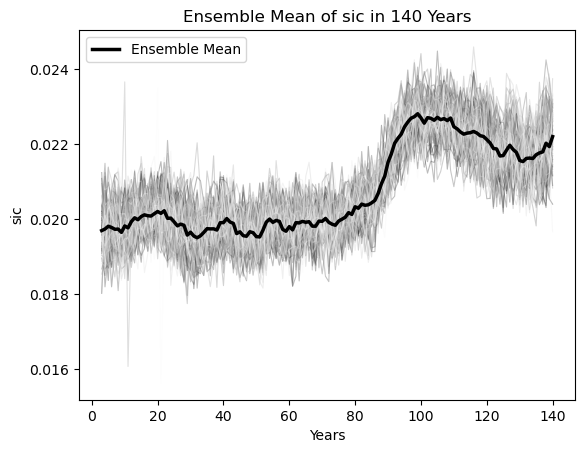

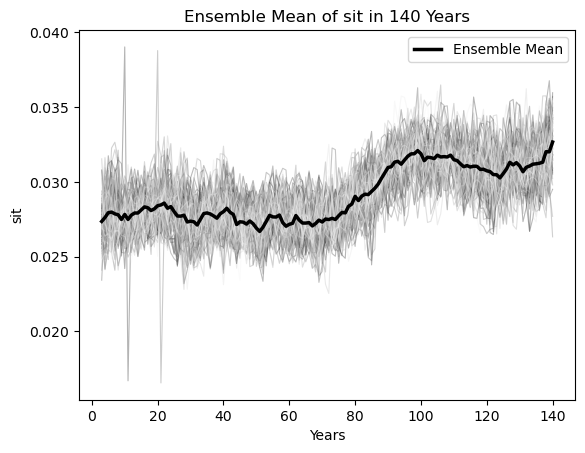

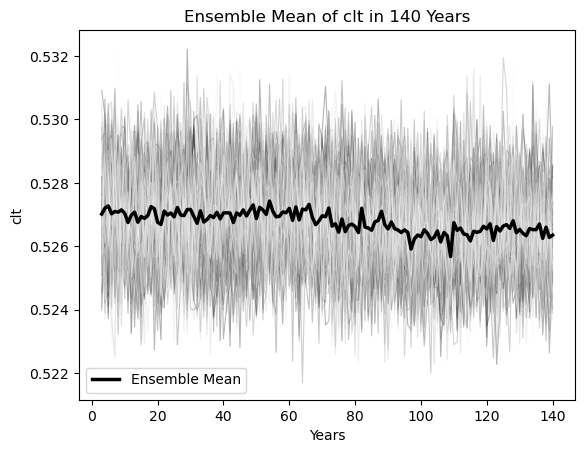

In [11]:
#paths=['combined_rst/','combined_rlut','combined_rss','combined_rls','combined_hfls','combined_hfss']
#varstrings=['rst','rlut','rss','rls','hfls','hfss']

#change names for sea ice cover and cloud cover
paths=['../data/other_vars/combined_sic/','../data/other_vars/combined_sit','../data/other_vars/combined_clt']
varstrings=['sic','sit','clt']

#varnames=[rst,rlut,rss,rls,hfls,hfss]
#plotting
for path in range(len(paths)):
    #each variable
    vardf=f"{varstrings[path]}_df"
    vardf= process_data(paths[path],varstrings[path])
    df_yearly = vardf.groupby(["Years", "Trajectory"])[varstrings[path]].mean().reset_index()
    plt.figure()
    sns.lineplot(data=df_yearly,x="Years",y=varstrings[path],hue="Trajectory",palette="gray",         
    linewidth=0.8,
    alpha=0.3,
    legend=False)

    df_mean = df_yearly.groupby("Years")[varstrings[path]].mean().reset_index()

    sns.lineplot(
        data=df_mean,
        x="Years",
        y=varstrings[path],
        color="black",
        linewidth=2.5,
        label="Ensemble Mean"
    )
    plt.title(f"Ensemble Mean of {varstrings[path]} in 140 Years")
    plt.savefig(f"mean_{varstrings[path]}.png")
    #plt.show()
    #plt.close()
'''
    #toa
    if (path==0):
        df_rst=df_yearly
    elif (path==1):
        df_rlut=df_yearly
        # Merge the two DataFrames on both "Years" and "Trajectory"
        df_combined = pd.merge(df_rst, df_rlut, on=["Years", "Trajectory"])
        
        # Create a new column which is the sum of rst and rss
        df_combined["total"] = df_combined["rst"] + df_combined["rlut"]
        plt.figure()
        # plot each trajectory timeseries
        sns.lineplot(data=df_combined, x="Years", y="total", hue="Trajectory",
                     palette="gray", linewidth=0.8, alpha=0.3, legend=False)
        
        # Compute the ensemble average (over trajectories) for each year
        df_mean = df_combined.groupby("Years")["total"].mean().reset_index()
        # Overlay the ensemble mean as a thick black line
        sns.lineplot(data=df_mean, x="Years", y="total", color="black", linewidth=2.5, label="Ensemble Mean")
        
        plt.title("Energy Budget at Top of Atmosphere ")
        plt.xlabel("Year")
        plt.ylabel("W/m²")
        plt.legend()
        plt.savefig(f"energy_budget_toa.png")
        #plt.show()
        #plt.close()

    #surface
    elif (path==2):
        df_rss=df_yearly
    elif (path==3):
        df_rls=df_yearly
    elif (path==4):
        df_hfls=df_yearly
    elif (path==5):
        df_hfss=df_yearly
        merged = pd.merge(df_rss, df_rls, on=["Years", "Trajectory"])
        merged = pd.merge(merged, df_hfls, on=["Years", "Trajectory"])
        merged = pd.merge(merged, df_hfss, on=["Years", "Trajectory"])
        merged['total'] = merged['rss'] + merged['rls'] + merged['hfls'] + merged['hfss']
        plt.figure()
        sns.lineplot(data=merged,x='Years',y='total',hue='Trajectory',palette='gray',linewidth=0.8, alpha=0.3,legend=False)
        surf_mean=merged.groupby("Years")["total"].mean().reset_index()
        sns.lineplot(data=surf_mean,x="Years",y="total",color="black",linewidth=2.5,label="Ensemble Mean")
        plt.title("Energy Budget at Surface")
        plt.xlabel("Year")
        plt.ylabel("W/m²")
        plt.savefig(f"energy_budget_surf.png")
        #plt.show()
        #plt.close()
'''        

In [2]:
def draw_maps(df, title, values, label, figname,project):
    # shift seam
    df = df.copy()
    df["lon"] = (df["lon"] + 180) % 360 - 180

    # drop rows with NaN in the field to be plotted
    df = df.dropna(subset=[values])

    # aggregate in case multiple points share a grid cell
    grid = (
        df.pivot_table(index="lat", columns="lon", values=values, aggfunc="mean")
          .sort_index()           # lats ascending
          .sort_index(axis=1)     # lons ascending
    )

    if grid.empty:
        raise ValueError("No data left to plot — pivot_table returned empty grid.")
    print("Pivot shape:", grid.shape)

    lats = grid.index.values
    lons = grid.columns.values

    # Basemap
    m = Basemap(projection=project, lat_0=30, lon_0=-50, resolution="l")
    m.drawcoastlines(linewidth=0.25)
    m.drawcountries(linewidth=0.25)
    m.fillcontinents(color="#4863A0", lake_color="#D3D3D3")
    m.drawmapboundary(fill_color="grey")
    m.drawmeridians(np.arange(0, 360, 30))
    m.drawparallels(np.arange(-90, 90, 30))

    lon_grid, lat_grid = np.meshgrid(lons, lats)
    x, y = m(lon_grid, lat_grid)

    cs = m.contourf(x, y, grid.values, levels=20, cmap="coolwarm")
    cbar = plt.colorbar(cs, orientation="vertical")
    cbar.set_label(label)

    plt.title(title)
    plt.savefig(figname, bbox_inches="tight", dpi=150)
    plt.show()


In [12]:
'''
Going to change this in the following way:
Instead of using the simulated differences, I am creating files from the control run 'on' state and 'off' state: 
'''
def spatial_data(path,var,snapshot_year):
    datasets = []
    traj_counter = 1
    for file in os.listdir(path):
        if file.endswith(".nc"):
            ds = xr.open_dataset(os.path.join(path, file), engine="netcdf4")
            # Get the full data array (time, lat, lon)
            da = ds[var]
            #convert to df
            df_ts = da.to_dataframe(name=var).reset_index()
            #print(df_ts.tail(20))
            
            df_ts["year"] = (df_ts["time"].astype(float) // 10000).astype(int)
            N=len(df_ts)/24576
            sim_list = np.repeat(np.arange(1, N+1), 24576).tolist()
            df_ts['sim_year']=sim_list
            df_ts['Trajectory']=traj_counter
            df_snapshot = df_ts.loc[df_ts["sim_year"] == snapshot_year].copy()
            #print("DF snapshot:",df_snapshot.head(10))
            
            datasets.append(df_snapshot)
            traj_counter+=1

    ds_combined = pd.concat(datasets)
    return ds_combined

In [13]:
for varname in range(len(varstrings)):
    #print(varname)
    numberstring=f"{varstrings[varname]}_two"
    #print(numberstring)
    numberstring = spatial_data(paths[varname],varstrings[varname],2)
    yearly_avg = numberstring.groupby(["year", "lat", "lon", "Trajectory"])[varstrings[varname]].mean().reset_index()
    averaged_traj = yearly_avg.groupby(["lat","lon"])[varstrings[varname]].mean().reset_index()
    #draw_maps(averaged_traj,f"Time-averaged {varstrings[varname]} in AMOC on State",varstrings[varname],'W/m²',
              #f"lats_{varstrings[varname]}.png","ortho")
    averaged_traj.to_csv(f"../data/other_vars/{varstrings[varname]}_on.csv",index=False)

In [15]:
for varname in range(len(varstrings)):
    #print(varname)
    numberstring=f"{varstrings[varname]}_hundred"
    #print(numberstring)
    numberstring = spatial_data(paths[varname],varstrings[varname],100)
    yearly_avg = numberstring.groupby(["year", "lat", "lon", "Trajectory"])[varstrings[varname]].mean().reset_index()
    averaged_traj = yearly_avg.groupby(["lat","lon"])[varstrings[varname]].mean().reset_index()
    #draw_maps(averaged_traj,f"Time-averaged {varstrings[varname]} in AMOC off State",varstrings[varname],'W/m²',
              #f"lats_{varstrings[varname]}_off.png","ortho")
    averaged_traj.to_csv(f"../data/other_vars/{varstrings[varname]}_off.csv",index=False)